# 03 -- Exploratory Data Analysis

**Project:** Uber Data Visualization and Analysis  
**Input:** `data/processed/uber_trips_cleaned.csv`  

Covers demand patterns, fare distributions, city comparisons, time-based trends, and KPI computation.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == 'notebooks'
    else Path.cwd().resolve()
)
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'uber_trips_cleaned.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['pickup_time', 'drop_time'])
df['pickup_date'] = pd.to_datetime(df['pickup_date'])

print(f'Loaded {len(df):,} rows x {df.shape[1]} columns')
print(f'Date range: {df["pickup_time"].min().date()} to {df["pickup_time"].max().date()}')

Loaded 49,997 rows x 23 columns
Date range: 2023-01-01 to 2023-02-04


## 1. Dataset Overview

In [2]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
trip_id,49997.0,NaN,NaN,NaN,24999.539172,1.0,12500.0,24999.0,37498.0,50000.0,14433.789861
driver_id,49997.0,NaN,NaN,NaN,5494.118947,1000.0,3233.0,5497.0,7746.0,9998.0,2601.396679
rider_id,49997.0,NaN,NaN,NaN,55040.449667,10001.0,32539.0,55164.0,77293.0,99998.0,25915.893574
city,49997,6,Boston,8454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,49997.0,NaN,NaN,NaN,38.998657,37.000009,37.99444,38.992587,39.999594,40.999937,1.155218
pickup_lng,49997.0,NaN,NaN,NaN,-97.486621,-121.999465,-109.819181,-97.464116,-85.19404,-73.001961,14.173477
drop_lat,49997.0,NaN,NaN,NaN,38.99876,36.953365,37.998265,38.99418,39.998843,41.047536,1.155674
drop_lng,49997.0,NaN,NaN,NaN,-97.486746,-122.047124,-109.817492,-97.464814,-85.201347,-72.963476,14.173467
distance_km,49997.0,NaN,NaN,NaN,7.008491,0.01,4.98,6.98,9.0,19.41,2.946332
fare_amount,49997.0,NaN,NaN,NaN,15.976964,1.08,11.51,15.43,19.91,50.67,6.273826


## 2. Trip Status Distribution

**Business question:** What proportion of trips are completed, cancelled, or no-show?

Trip Status Breakdown:
  Completed   : 42,538  (85.08%)
  Cancelled   : 4,984  (9.97%)
  No-Show     : 2,475  (4.95%)


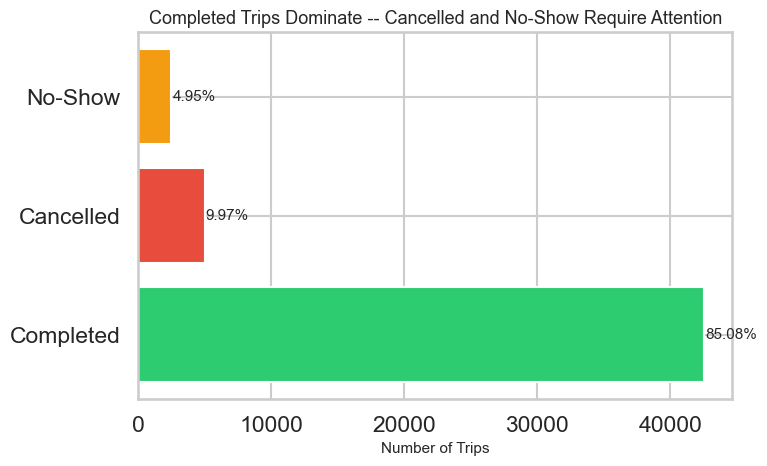

In [3]:
status_counts = df['status'].value_counts()
status_pct = (status_counts / len(df) * 100).round(2)

print('Trip Status Breakdown:')
for s, c in status_counts.items():
    print(f'  {s:<12}: {c:,}  ({status_pct[s]}%)')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(status_counts.index, status_counts.values, color=['#2ecc71', '#e74c3c', '#f39c12'])
for bar, pct in zip(bars, status_pct.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=11)
ax.set_xlabel('Number of Trips')
ax.set_title('Completed Trips Dominate -- Cancelled and No-Show Require Attention')
plt.tight_layout()
plt.show()

**Insight:** Assess the completion rate as the primary service reliability KPI.

## 3. City-Level Trip Volume

**Business question:** Which cities drive the most trip activity?

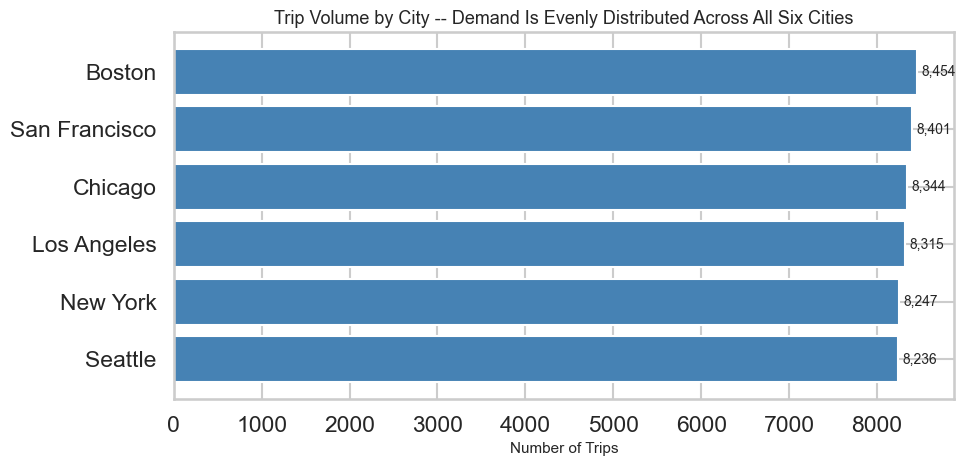

In [4]:
city_counts = df['city'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(city_counts.index, city_counts.values, color='steelblue')
for i, v in enumerate(city_counts.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=10)
ax.set_xlabel('Number of Trips')
ax.set_title('Trip Volume by City -- Demand Is Evenly Distributed Across All Six Cities')
plt.tight_layout()
plt.show()

## 4. Payment Method Distribution

**Business question:** What payment method do riders prefer?

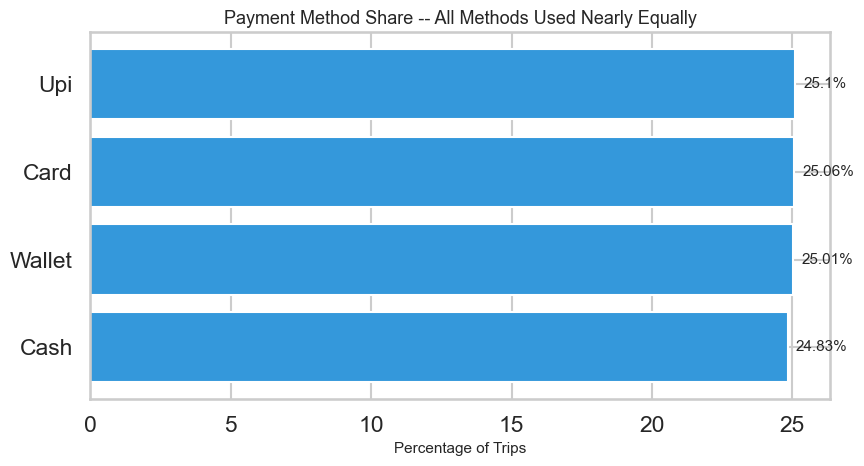

In [5]:
pay_pct = df['payment_method'].value_counts(normalize=True).mul(100).round(2).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(pay_pct.index, pay_pct.values, color='#3498db')
for i, v in enumerate(pay_pct.values):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=11)
ax.set_xlabel('Percentage of Trips')
ax.set_title('Payment Method Share -- All Methods Used Nearly Equally')
plt.tight_layout()
plt.show()

## 5. Fare Amount Distribution

**Business question:** What does the fare distribution look like? Are most trips low-value or high-value?

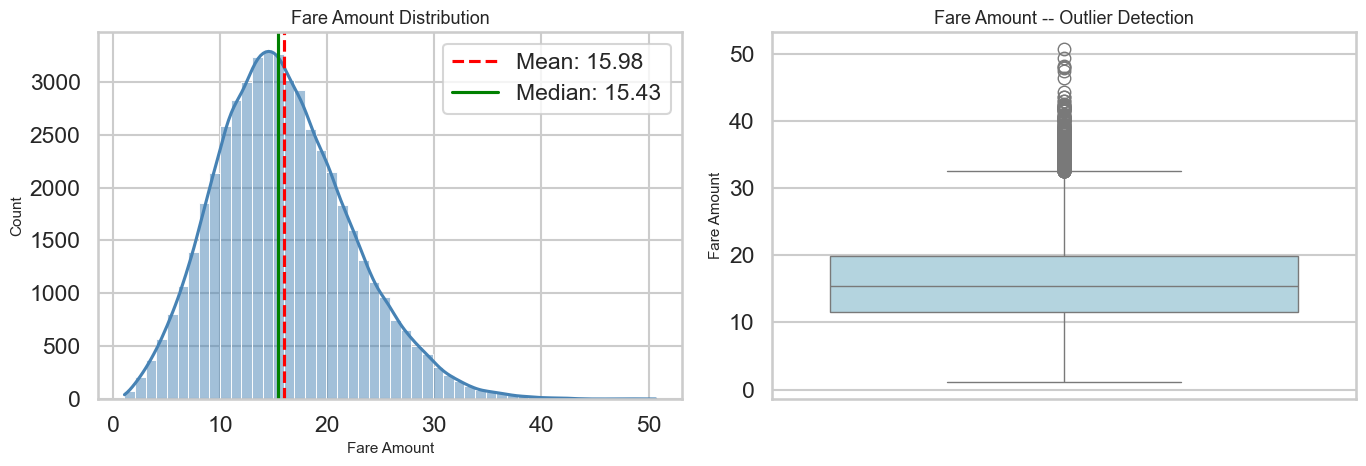

Mean fare   : 15.98
Median fare : 15.43
Skewness    : 0.4817


In [6]:
fare_mean = df['fare_amount'].mean()
fare_median = df['fare_amount'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['fare_amount'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(fare_mean, color='red', linestyle='--', label=f'Mean: {fare_mean:.2f}')
axes[0].axvline(fare_median, color='green', linestyle='-', label=f'Median: {fare_median:.2f}')
axes[0].set_title('Fare Amount Distribution')
axes[0].set_xlabel('Fare Amount')
axes[0].legend()

sns.boxplot(y=df['fare_amount'], ax=axes[1], color='lightblue')
axes[1].set_title('Fare Amount -- Outlier Detection')
axes[1].set_ylabel('Fare Amount')

plt.tight_layout()
plt.show()

print(f'Mean fare   : {fare_mean:.2f}')
print(f'Median fare : {fare_median:.2f}')
print(f'Skewness    : {df["fare_amount"].skew():.4f}')

## 6. Trip Distance Distribution

**Business question:** What is the typical trip distance?

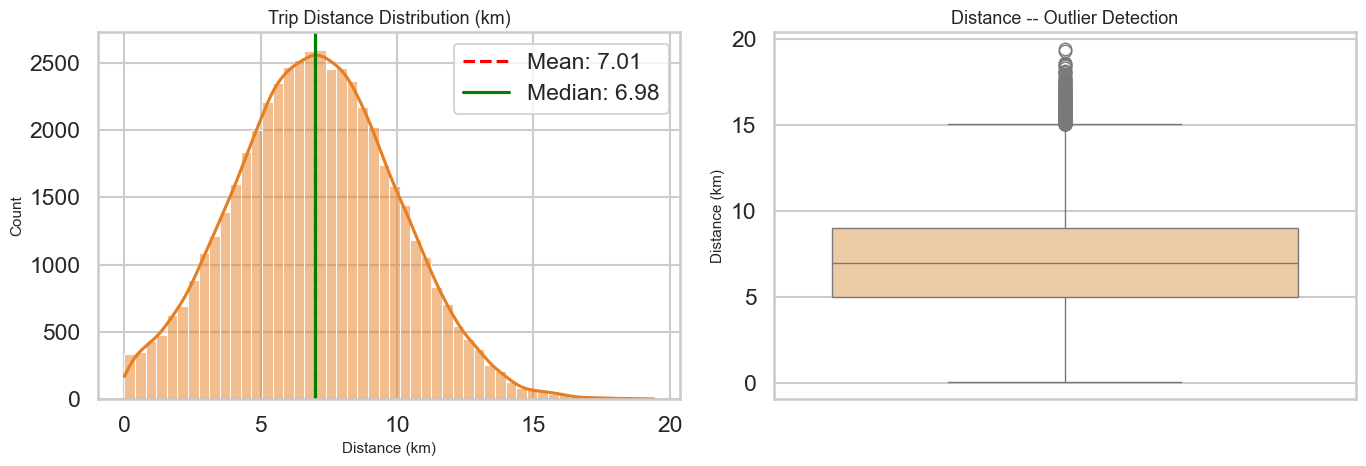

In [7]:
dist_mean = df['distance_km'].mean()
dist_median = df['distance_km'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['distance_km'], bins=50, kde=True, ax=axes[0], color='#e67e22')
axes[0].axvline(dist_mean, color='red', linestyle='--', label=f'Mean: {dist_mean:.2f}')
axes[0].axvline(dist_median, color='green', linestyle='-', label=f'Median: {dist_median:.2f}')
axes[0].set_title('Trip Distance Distribution (km)')
axes[0].set_xlabel('Distance (km)')
axes[0].legend()

sns.boxplot(y=df['distance_km'], ax=axes[1], color='#f9ca9a')
axes[1].set_title('Distance -- Outlier Detection')
axes[1].set_ylabel('Distance (km)')

plt.tight_layout()
plt.show()

## 7. Trip Duration Distribution

**Business question:** How long do most Uber trips take?

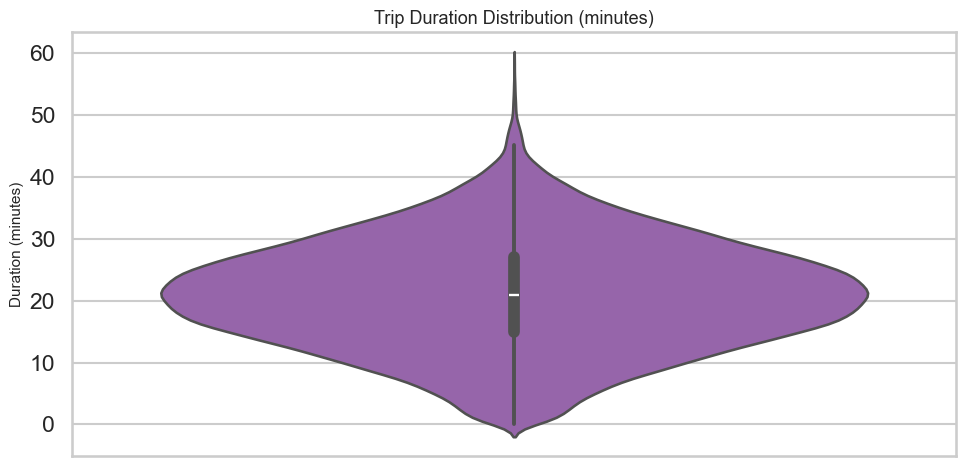

count    49997.00
mean        21.03
std          8.84
min          0.03
25%         14.93
50%         20.93
75%         27.00
max         58.23
Name: trip_duration_mins, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(y=df['trip_duration_mins'], ax=ax, color='#9b59b6', inner='box')
ax.set_title('Trip Duration Distribution (minutes)')
ax.set_ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

print(df['trip_duration_mins'].describe().round(2))

## 8. Hourly Demand Pattern

**Business question:** What hours of the day see the highest trip demand?

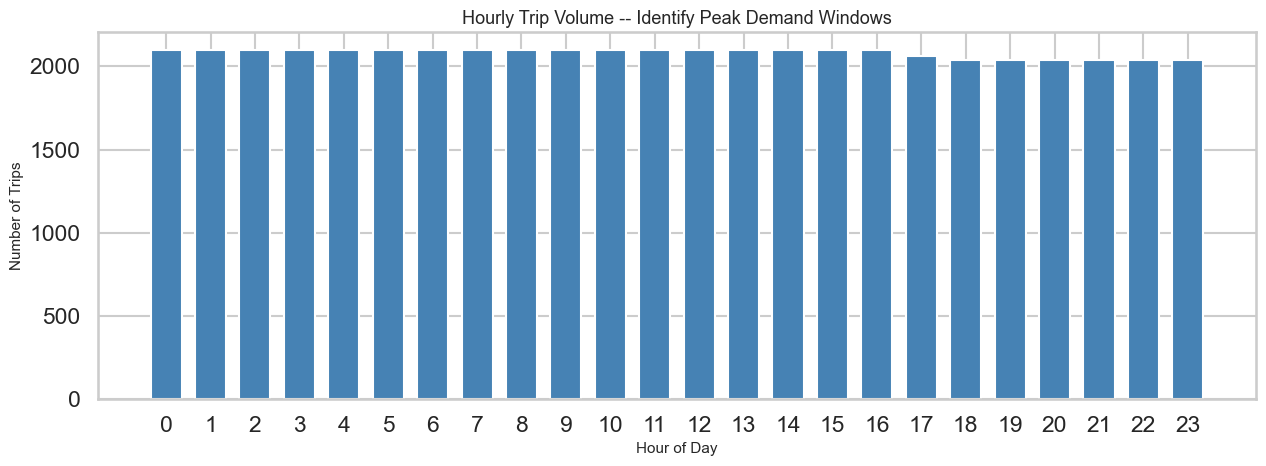

In [9]:
hourly = df.groupby('pickup_hour').size().reset_index(name='trip_count')

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(hourly['pickup_hour'], hourly['trip_count'], color='steelblue', width=0.7)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Trips')
ax.set_xticks(range(0, 24))
ax.set_title('Hourly Trip Volume -- Identify Peak Demand Windows')
plt.tight_layout()
plt.show()

## 9. Day-of-Week Demand Pattern

**Business question:** Which days of the week have the most trips?

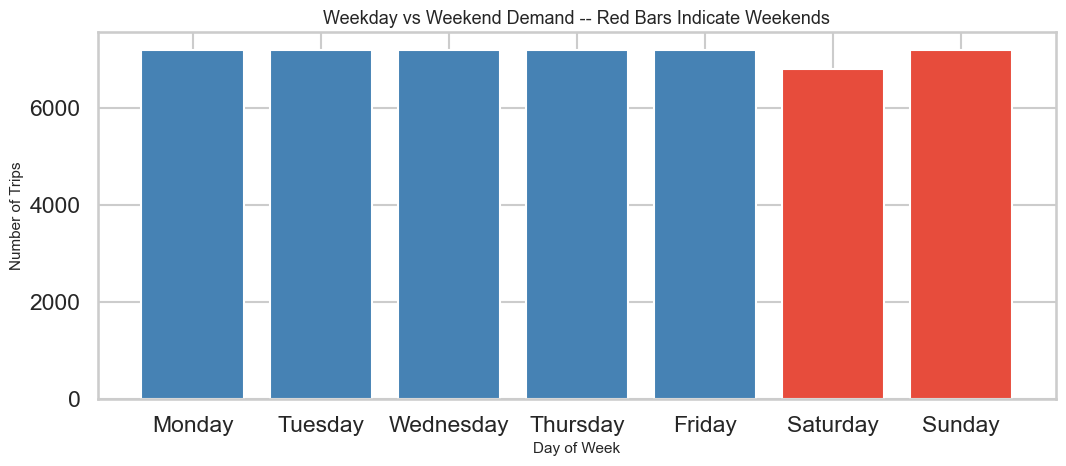

In [10]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['pickup_day'].value_counts().reindex(day_order)

colors = ['#e74c3c' if d in ['Saturday', 'Sunday'] else 'steelblue' for d in day_order]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(day_counts.index, day_counts.values, color=colors)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Trips')
ax.set_title('Weekday vs Weekend Demand -- Red Bars Indicate Weekends')
plt.tight_layout()
plt.show()

## 10. Time-of-Day Segment Analysis

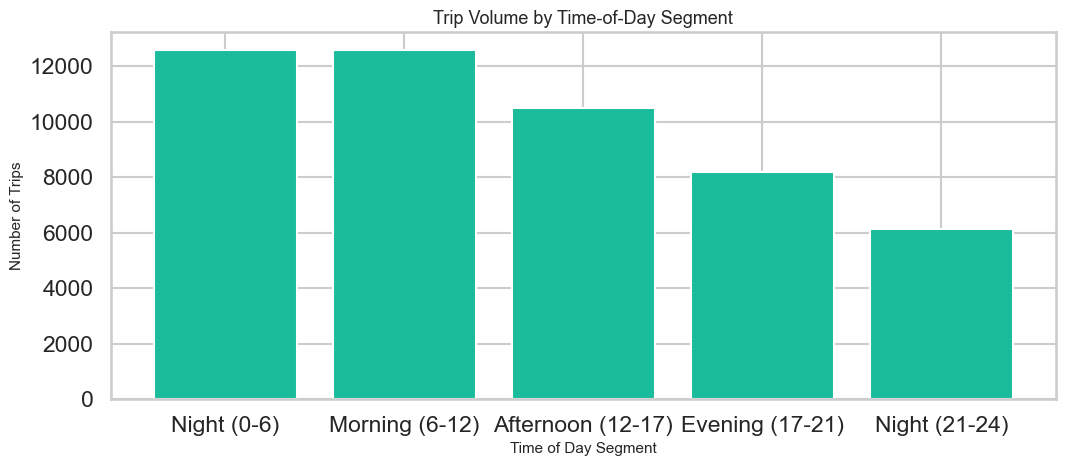

In [11]:
tod_order = ['Night (0-6)', 'Morning (6-12)', 'Afternoon (12-17)', 'Evening (17-21)', 'Night (21-24)']
tod_counts = df['time_of_day'].value_counts().reindex(tod_order)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(tod_counts.index, tod_counts.values, color='#1abc9c')
ax.set_xlabel('Time of Day Segment')
ax.set_ylabel('Number of Trips')
ax.set_title('Trip Volume by Time-of-Day Segment')
plt.tight_layout()
plt.show()

## 11. Daily Trip Volume Trend (Full Month)

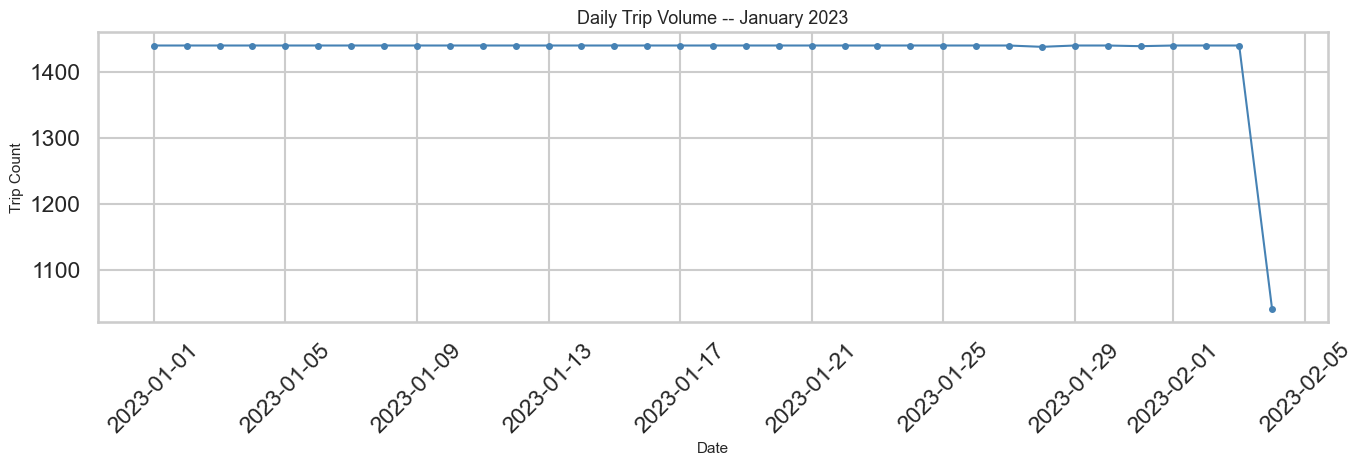

In [12]:
daily_volume = df.groupby('pickup_date').size().reset_index(name='trip_count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_volume['pickup_date'], daily_volume['trip_count'],
        marker='o', markersize=4, linewidth=1.5, color='steelblue')
ax.set_xlabel('Date')
ax.set_ylabel('Trip Count')
ax.set_title('Daily Trip Volume -- January 2023')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Heatmap -- Trips by Hour and Day of Week

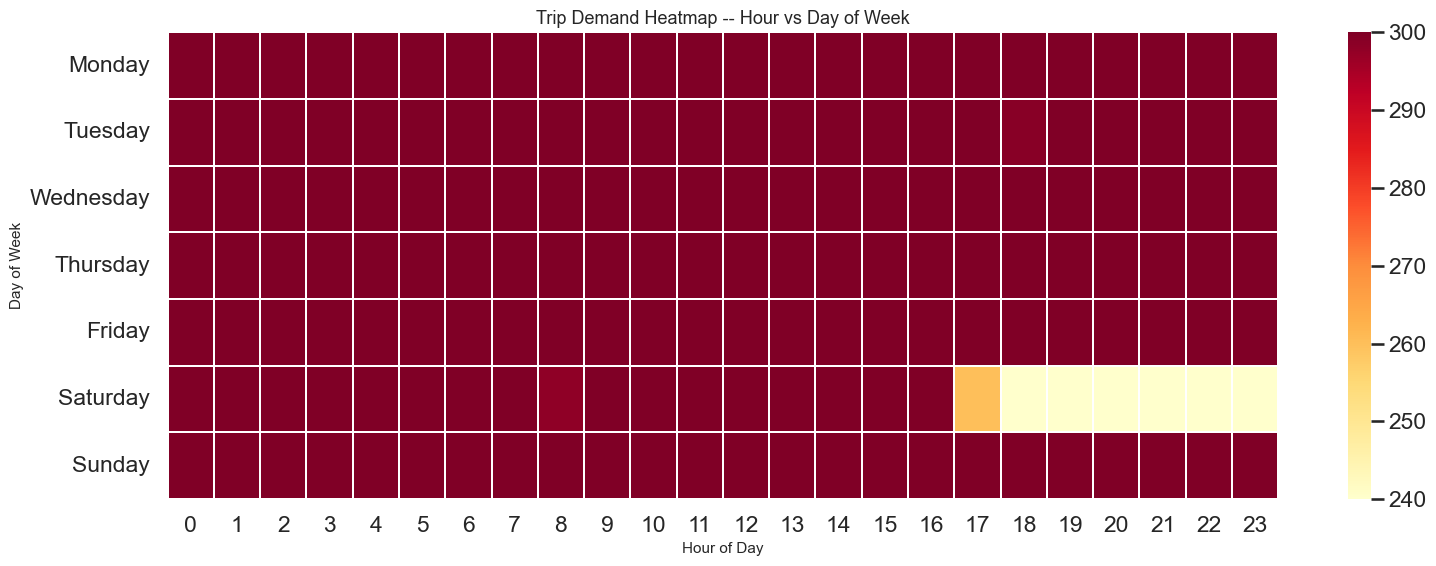

In [13]:
heatmap_data = df.groupby(['pickup_day', 'pickup_hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Trip Demand Heatmap -- Hour vs Day of Week')
plt.tight_layout()
plt.show()

## 13. Average Fare by City

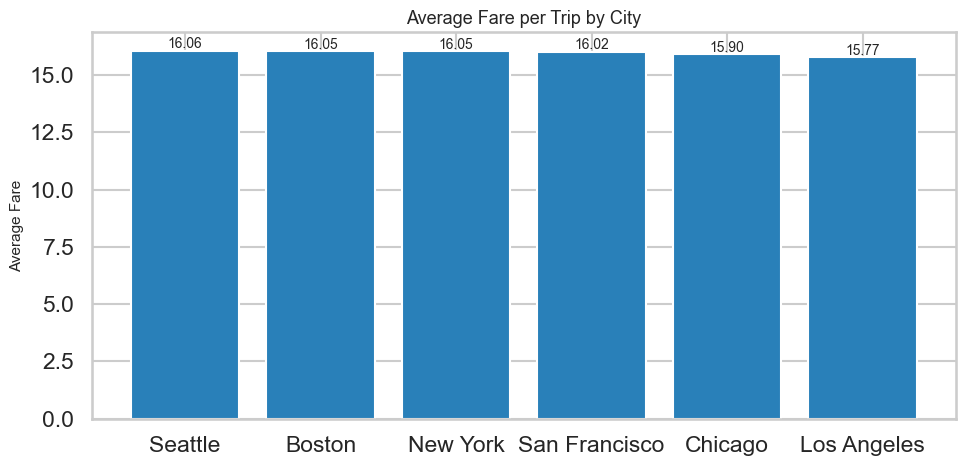

In [14]:
city_fare = df.groupby('city')['fare_amount'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(city_fare.index, city_fare.values, color='#2980b9')
for i, v in enumerate(city_fare.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)
ax.set_ylabel('Average Fare')
ax.set_title('Average Fare per Trip by City')
plt.tight_layout()
plt.show()

## 14. Fare vs Distance (Scatter)

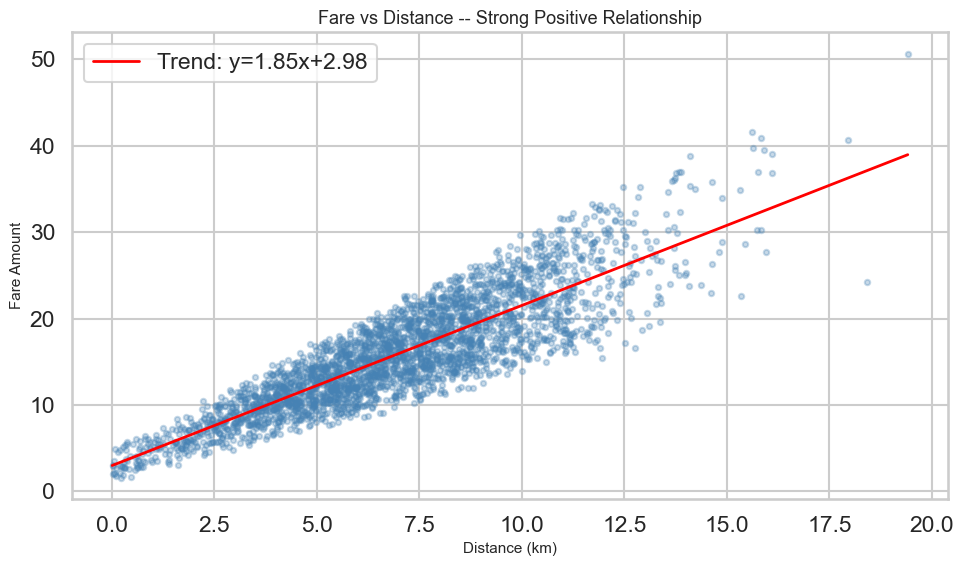

Pearson correlation (fare vs distance): 0.8706


In [15]:
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['distance_km'], sample['fare_amount'],
           alpha=0.3, s=15, color='steelblue')

m, b = np.polyfit(df['distance_km'], df['fare_amount'], 1)
x_line = np.linspace(df['distance_km'].min(), df['distance_km'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend: y={m:.2f}x+{b:.2f}')

ax.set_xlabel('Distance (km)')
ax.set_ylabel('Fare Amount')
ax.set_title('Fare vs Distance -- Strong Positive Relationship')
ax.legend()
plt.tight_layout()
plt.show()

corr = df['fare_amount'].corr(df['distance_km'])
print(f'Pearson correlation (fare vs distance): {corr:.4f}')

## 15. Cancellation Rate by City

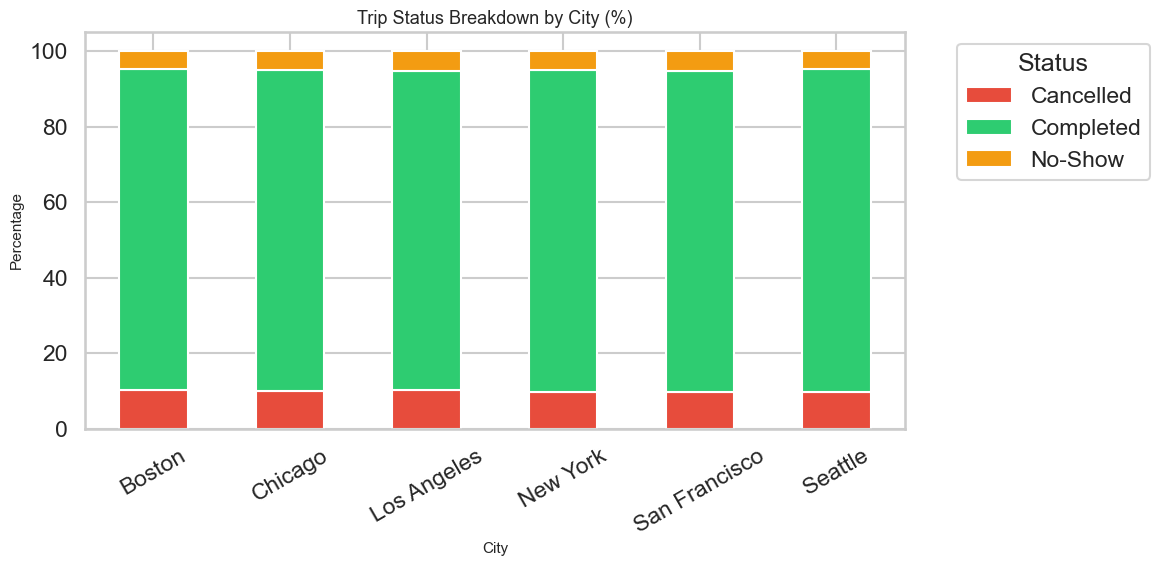

In [16]:
city_status = df.groupby(['city', 'status']).size().unstack(fill_value=0)
city_status_pct = city_status.div(city_status.sum(axis=1), axis=0).mul(100).round(2)

city_status_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                      color=['#e74c3c', '#2ecc71', '#f39c12'])
plt.title('Trip Status Breakdown by City (%)')
plt.ylabel('Percentage')
plt.xlabel('City')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 16. Fare per KM by City -- Pricing Efficiency

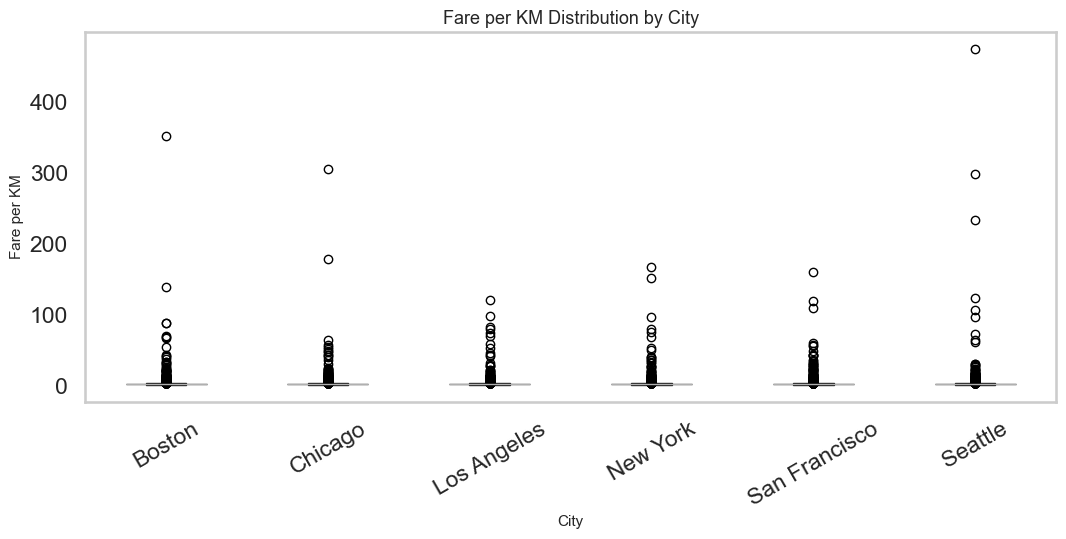

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
df.boxplot(column='fare_per_km', by='city', ax=ax,
           grid=False, patch_artist=True)
ax.set_title('Fare per KM Distribution by City')
ax.set_xlabel('City')
ax.set_ylabel('Fare per KM')
plt.suptitle('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 17. Revenue Contribution by City (Pareto Analysis)

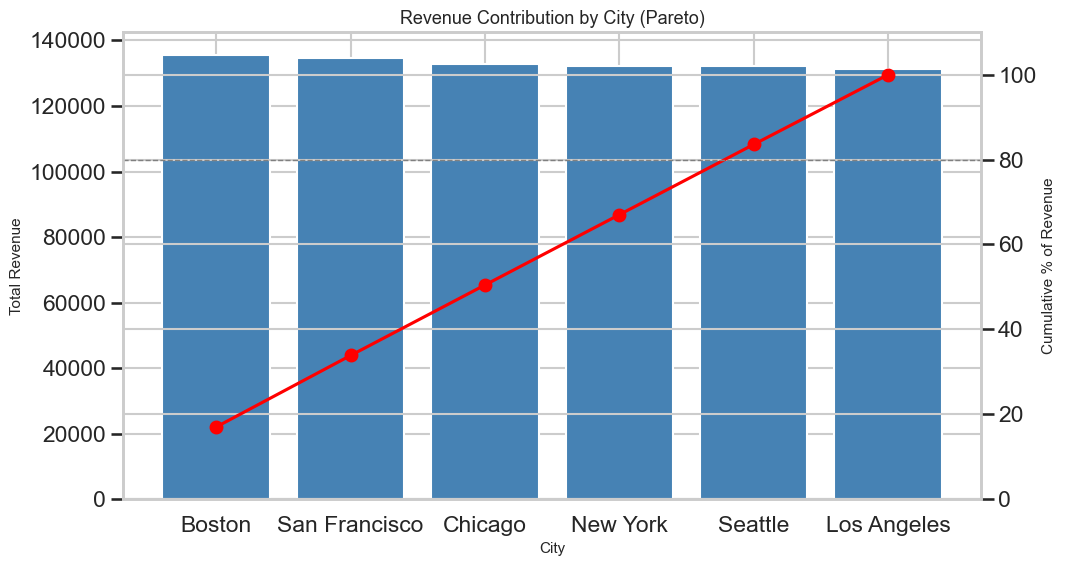

Revenue by city:
  Boston         : 135,704.41
  San Francisco  : 134,611.24
  Chicago        : 132,689.49
  New York       : 132,351.73
  Seattle        : 132,287.32
  Los Angeles    : 131,156.08


In [18]:
city_revenue = df.groupby('city')['fare_amount'].sum().sort_values(ascending=False)
cum_pct = city_revenue.cumsum() / city_revenue.sum() * 100

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(city_revenue.index, city_revenue.values, color='steelblue')
ax1.set_ylabel('Total Revenue')
ax1.set_xlabel('City')
ax1.set_title('Revenue Contribution by City (Pareto)')

ax2 = ax1.twinx()
ax2.plot(city_revenue.index, cum_pct.values, color='red', marker='o')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative % of Revenue')
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.show()

print('Revenue by city:')
for city, rev in city_revenue.items():
    print(f'  {city:<15}: {rev:,.2f}')

## 18. Weekend vs Weekday -- Fare and Distance Comparison

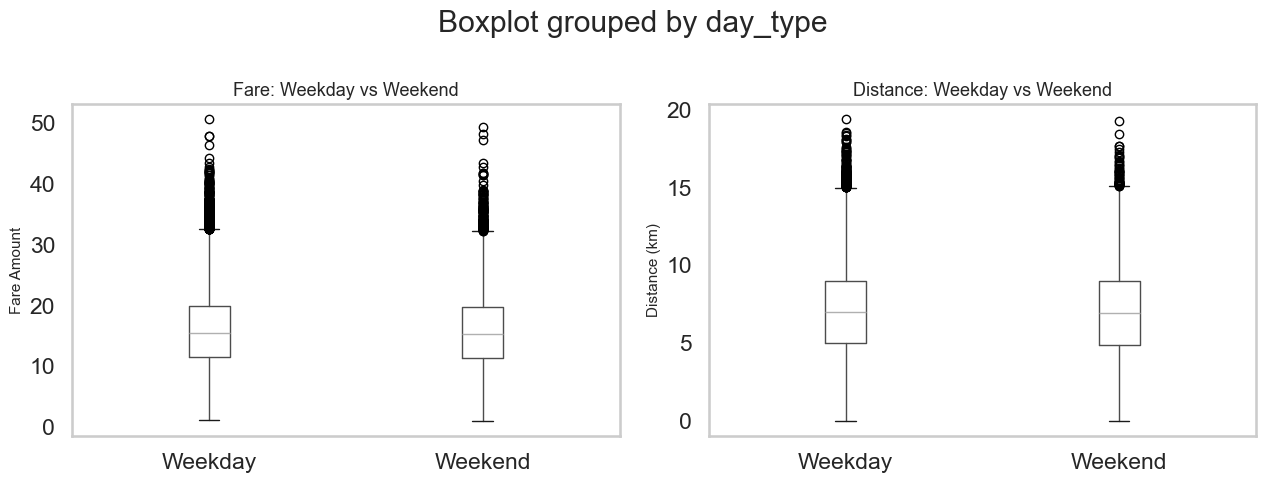

Average metrics by day type:
          fare_amount  distance_km  trip_duration_mins
day_type                                              
Weekday         16.00         7.02               21.07
Weekend         15.91         6.97               20.92


In [19]:
df['day_type'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.boxplot(column='fare_amount', by='day_type', ax=axes[0], grid=False)
axes[0].set_title('Fare: Weekday vs Weekend')
axes[0].set_xlabel('')
axes[0].set_ylabel('Fare Amount')
plt.suptitle('')

df.boxplot(column='distance_km', by='day_type', ax=axes[1], grid=False)
axes[1].set_title('Distance: Weekday vs Weekend')
axes[1].set_xlabel('')
axes[1].set_ylabel('Distance (km)')

plt.tight_layout()
plt.show()

summary = df.groupby('day_type')[['fare_amount', 'distance_km', 'trip_duration_mins']].mean().round(2)
print('Average metrics by day type:')
print(summary)

## 19. KPI Summary Table

In [20]:
total = len(df)
completed = (df['status'] == 'Completed').sum()
cancelled = (df['status'] == 'Cancelled').sum()
noshow    = (df['status'] == 'No-Show').sum()

kpis = {
    'Total Trips'              : f'{total:,}',
    'Completion Rate'          : f'{completed / total * 100:.2f}%',
    'Cancellation Rate'        : f'{cancelled / total * 100:.2f}%',
    'No-Show Rate'             : f'{noshow / total * 100:.2f}%',
    'Average Fare'             : f'{df["fare_amount"].mean():.2f}',
    'Average Distance (km)'    : f'{df["distance_km"].mean():.2f}',
    'Average Duration (mins)'  : f'{df["trip_duration_mins"].mean():.2f}',
    'Average Fare per KM'      : f'{df["fare_per_km"].mean():.2f}',
    'Weekend Trip Share'       : f'{df["is_weekend"].mean() * 100:.2f}%',
}

print('=' * 45)
print('  KEY PERFORMANCE INDICATORS')
print('=' * 45)
for k, v in kpis.items():
    print(f'  {k:<30}: {v}')
print('=' * 45)

  KEY PERFORMANCE INDICATORS
  Total Trips                   : 49,997
  Completion Rate               : 85.08%
  Cancellation Rate             : 9.97%
  No-Show Rate                  : 4.95%
  Average Fare                  : 15.98
  Average Distance (km)         : 7.01
  Average Duration (mins)       : 21.03
  Average Fare per KM           : 2.61
  Weekend Trip Share            : 28.00%


---

**Next Step:** `04_statistical_analysis.ipynb` -- Hypothesis Testing and Statistical Analysis